# Project Name - Olympic Medal Count by Country

**Project Type** - Exploratory Data Analysis (EDA)

**Contribution** - Chanda Sushmasri



 This project focuses on analyzing historical Olympic data to understand patterns in medal distribution, country-wise performance, and sport dominance across different Olympic years. The primary objective of this project was to explore how countries have performed over time and to derive meaningful insights using data analysis and visualization techniques. The project emphasizes not only identifying top-performing countries but also understanding performance trends and efficiency through deeper analytical approaches.

The dataset used in this project contains over 120 years of Olympic history, including detailed information such as athlete records, country names, year of participation, sport categories, and medal types. Since the dataset is large and contains many attributes that are not directly relevant to the project objective, the first step involved data cleaning and preprocessing. Only essential columns such as country (Team/NOC), year, sport, and medal were selected for analysis. Additionally, all rows without medal information were removed to ensure that the analysis focused strictly on medal-winning performances. This step helped reduce noise in the dataset and improved the clarity and accuracy of the results.

To enhance the usability and interpretability of the dataset, a country mapping dataset was merged using the National Olympic Committee (NOC) codes. This allowed conversion of short country codes into full country names, making the data more readable and suitable for visualization. During this process, real-world data inconsistencies such as mismatched or missing country names were handled carefully. Furthermore, a population dataset was incorporated into the analysis to calculate medals per capita. This step introduced an advanced analytical perspective by enabling comparison of performance relative to population size rather than relying solely on total medal counts.

The analysis was carried out in multiple stages. Initially, total medal counts were calculated for each country to identify the most successful nations in Olympic history. This provided a general overview of global performance and highlighted dominant countries. Following this, a year-wise analysis was performed to observe how medal distribution has evolved over time. Bar plots were used to visualize the number of medals awarded in each Olympic year, which helped identify trends such as growth in participation, expansion of events, and increasing competitiveness.

In addition to country and year-based analysis, sport-wise dominance was also examined. By grouping the dataset based on sports and counting the number of medals, it was observed that certain sports such as Athletics and Swimming consistently contribute the highest number of medals. This indicates that these sports have a larger number of events and higher participation levels, making them key contributors to overall medal counts.

One of the most significant aspects of this project is the calculation of medals per capita. By integrating population data with medal counts, a new performance metric was introduced to evaluate efficiency. This analysis revealed that smaller countries, such as Liechtenstein and Norway, often outperform larger nations when results are adjusted for population size. This provides a more balanced and insightful comparison, highlighting that performance efficiency is not solely dependent on the size of the country.

Overall, this project demonstrates the effective application of Exploratory Data Analysis (EDA) techniques on real-world datasets. It highlights the importance of data preprocessing, dataset integration, handling inconsistencies, and visualizing results to extract meaningful insights. The project successfully fulfills its objectives and provides a comprehensive understanding of Olympic performance trends across countries, years, and sports. It also showcases how data-driven approaches can be used to uncover deeper insights beyond surface-level observations.

## GitHub Link -

https://github.com/sushmasriC/Exploratory-Data-Analysis-EDA-

## Problem Statement

To analyze Olympic data to understand country-wise medal performance across years, sport dominance, and evaluate performance efficiency using medals per capita.

# Let's Begin !

## 1. Know Your Data

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('/content/athlete_events.csv')
noc = pd.read_csv('/content/noc_regions.csv')
pop = pd.read_csv('/content/population_by_country_2020.csv')

In [13]:
# Dataset First View
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [14]:
# Dataset Rows & Columns count
df.shape

(271116, 15)

In [15]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


### What did you know about your dataset?

*   The dataset contains information about Olympic athletes, including their personal details, sports, events, and medals.
*  It includes both numerical and categorical data across multiple years.
*   Some columns have missing values, especially for physical attributes and medals.
*   Additional datasets help in analyzing country-wise performance and population-based insights.



## 2. Understanding Your Variables

In [16]:
df.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')



*   The main dataset contains over 120 years of Olympic data, including country, year, sport, and medal information.
*   Only relevant columns were selected and non-medal records were removed to focus on medal-winning performances.

*   Only relevant columns were selected and non-medal records were removed to focus on medal-winning performances.





#variables description




1.   NOC – 3-letter country code representing the National Olympic Committee
2.   Team - Name of the country participating in the Olympics

1.  Name of the country participating in the Olympics
2.  Year – Year in which the Olympic event took place

1.   Sport – Type of sport in which the athlete participated






#Check Unique values for each variables


In [17]:
# Unique values for each variable
df_clean = df[['Team', 'NOC', 'Year', 'Sport', 'Medal']]
df_clean = df_clean[df_clean['Medal'].notna()]

In [18]:
df_clean.nunique().to_frame(name="Unique Count")

,Unique Count
Team,498
NOC,149
Year,35
Sport,66
Medal,3


## 3. Data Wrangling

In [19]:
# Merge with country dataset
df_final = df_clean.merge(noc, on='NOC', how='left')

In [20]:
# Removing unnecessary column
df_final = df_final.drop(columns=['notes'])

In [21]:
# Removing rows with missing country names
df_final = df_final[df_final['region'].notna()]

In [22]:
# Removing rows with missing country names
df_final = df_final[df_final['region'].notna()]

## 4. Data Visualization, Storytelling & Experimenting with charts : Understand the relationships between variables

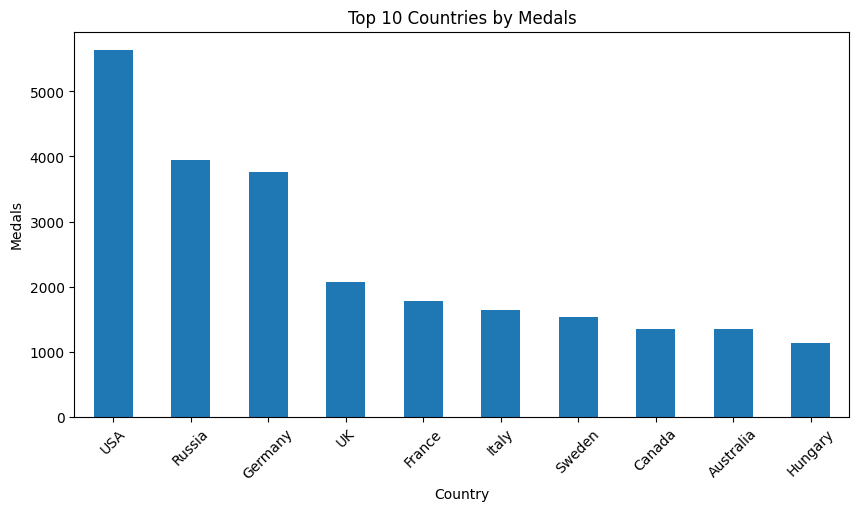

In [23]:
country_medals = df_final['region'].value_counts().head(10)

country_medals.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries by Medals")
plt.xlabel("Country")
plt.ylabel("Medals")
plt.xticks(rotation=45)
plt.show()

#Why did you pick this specific chart?
A bar chart was chosen because it is effective for comparing values across different categories. In this case, it clearly shows the medal counts of the top 10 countries, making it easy to compare their performance visually.

#What are the insights found from the chart?
The chart shows that the United States has the highest number of medals, significantly outperforming other countries. Russia and Germany also have strong performances, while the remaining countries have comparatively lower medal counts. This highlights a clear gap between top-performing nations and others.

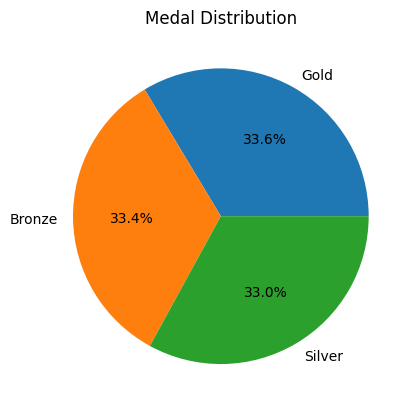

In [24]:
df_final['Medal'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Medal Distribution")
plt.ylabel("")
plt.show()

#Why did you pick this specific chart?
A pie chart was selected because it is best suited to show the proportion of each medal type in the overall dataset. It helps in understanding how Gold, Silver, and Bronze medals are distributed as percentages.
#What are the insights found from the chart?
The chart shows that Gold, Silver, and Bronze medals are distributed almost equally, each contributing nearly one-third of the total medals. This indicates a balanced medal distribution in the Olympic dataset, with no major imbalance among medal types.

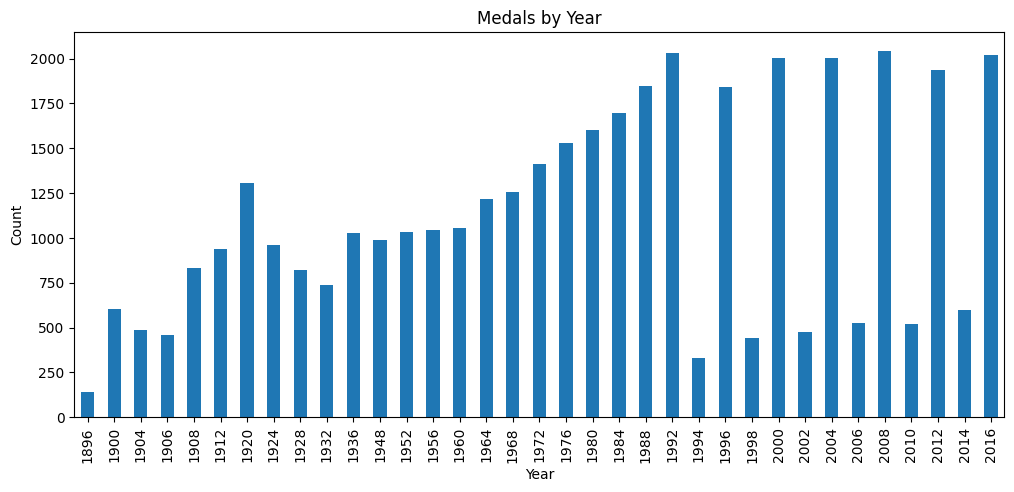

In [25]:
year_medals = df_final.groupby('Year')['Medal'].count()

year_medals.plot(kind='bar', figsize=(12,5))
plt.title("Medals by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

#Why did you pick this specific chart?
A bar chart was chosen because it clearly compares medal counts across different Olympic years. It is effective for showing changes over time and helps easily identify years with higher or lower medal counts.
#What are the insights found from the chart?
The chart shows that the total number of medals has generally increased over the years, which indicates growth in Olympic participation and the addition of more events. Recent years have significantly higher medal counts compared to early Olympic years, reflecting the expansion of the Games over time.

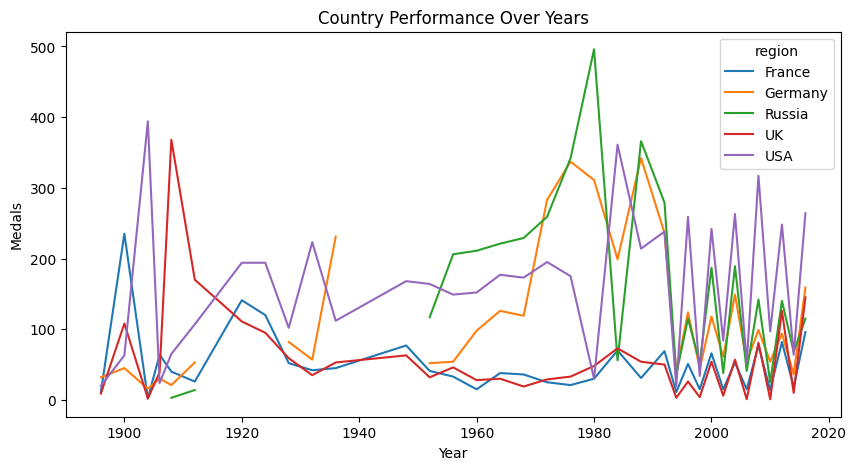

In [26]:
top_countries = df_final['region'].value_counts().head(5).index

filtered = df_final[df_final['region'].isin(top_countries)]

pivot = filtered.pivot_table(index='Year', columns='region', values='Medal', aggfunc='count')

pivot.plot(figsize=(10,5))
plt.title("Country Performance Over Years")
plt.ylabel("Medals")
plt.show()

#Why did you pick this specific chart?
A line chart was chosen because it is ideal for showing trends over time and comparing multiple countries across Olympic years. It makes it easy to observe how each country’s medal performance changes and how their trends differ over time.
#What are the insights found from the chart?
The chart shows that countries such as the USA and Russia have consistently strong performances across multiple Olympic years. Some countries show sharp peaks in certain years, indicating exceptional performances during those Olympics. Overall, the graph highlights how country dominance changes over time and reveals long-term performance trends.

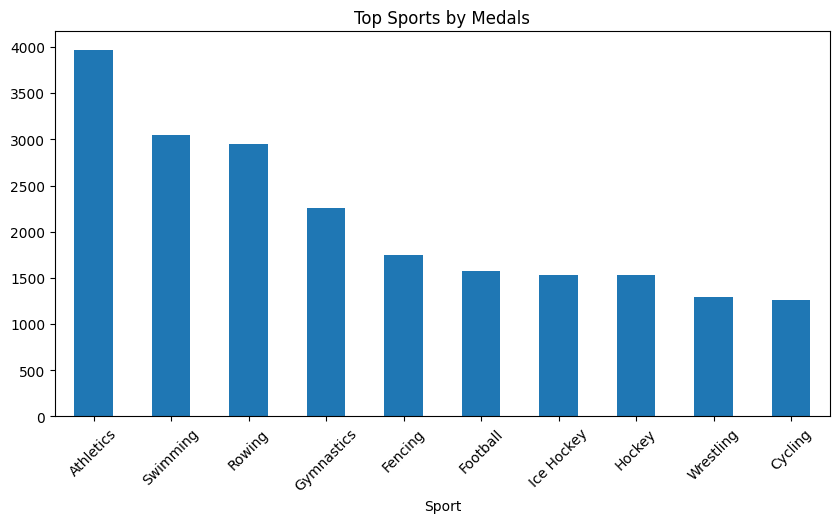

In [27]:
sport_medals = df_final['Sport'].value_counts().head(10)

sport_medals.plot(kind='bar', figsize=(10,5))
plt.title("Top Sports by Medals")
plt.xticks(rotation=45)
plt.show()

#Why did you pick this specific chart?
A bar chart was selected because it is the most effective way to compare medal counts across different sports categories. It clearly highlights which sports contribute the highest number of medals.
#What are the insights found from the chart?
The chart shows that Athletics has the highest medal count, followed by Swimming and Rowing. This indicates that these sports dominate the Olympics in terms of medal opportunities and participation. Sports like Wrestling and Cycling have comparatively fewer medals among the top categories.

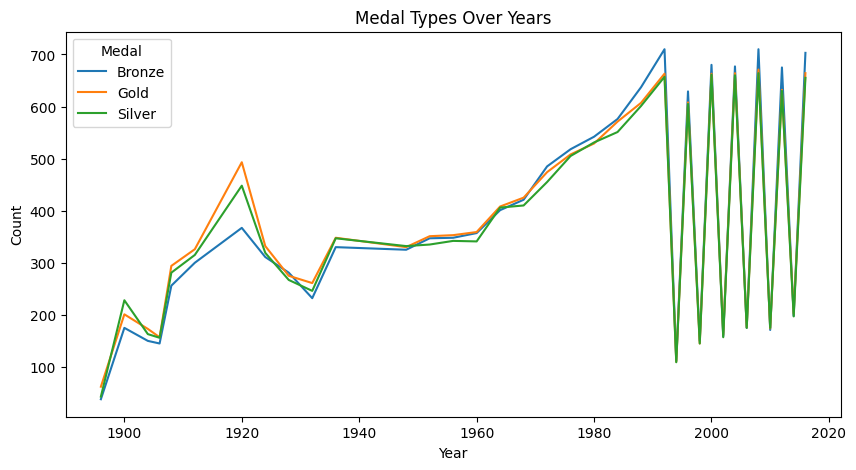

In [28]:
medal_year = df_final.groupby(['Year', 'Medal']).size().unstack()

medal_year.plot(figsize=(10,5))
plt.title("Medal Types Over Years")
plt.ylabel("Count")
plt.show()

#Why did you pick this specific chart?
A line chart was chosen because it is ideal for showing how different medal types change over time. It allows easy comparison of Gold, Silver, and Bronze medal trends across Olympic years.
#What are the insights found from the chart?
The chart shows that all three medal types follow a similar increasing trend over the years, indicating growth in Olympic events and participation. In recent years, the counts of Gold, Silver, and Bronze medals have become much higher compared to earlier years, showing the expansion of the Olympics.

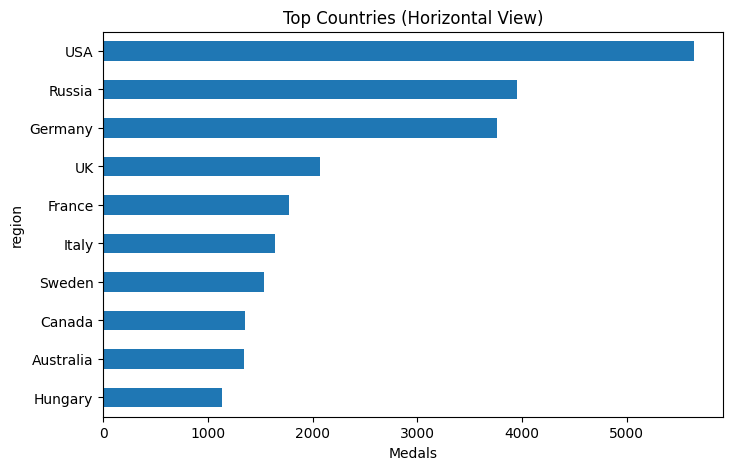

In [29]:
country_medals.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Top Countries (Horizontal View)")
plt.xlabel("Medals")
plt.show()

#Why did you pick this specific chart?
A horizontal bar chart was chosen because it improves readability when comparing multiple countries with long labels. It makes ranking and comparison of medal counts clearer than a vertical bar chart.
#What are the insights found from the chart?
The chart clearly shows that the USA leads by a large margin in total medal count, followed by Russia and Germany. Other countries such as the UK, France, and Italy also have strong performances but significantly fewer medals compared to the top three nations.

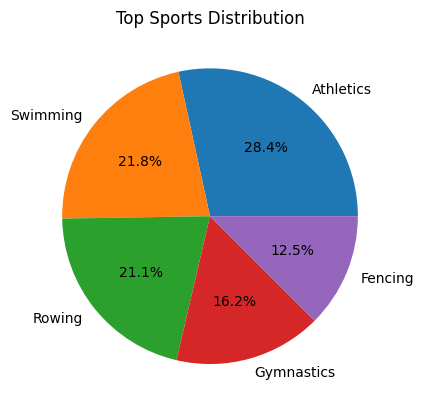

In [30]:
df_final['Sport'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title("Top Sports Distribution")
plt.ylabel("")
plt.show()

#Why did you pick this specific chart?
A pie chart was chosen because it effectively shows the percentage contribution of the top sports to the total medal count. It helps visualize how much each sport contributes relative to the others.
#What are the insights found from the chart?
The chart shows that Athletics contributes the highest share of medals among the top sports, followed by Swimming and Rowing. Gymnastics and Fencing contribute smaller portions, indicating comparatively lower medal opportunities within the selected top sports.

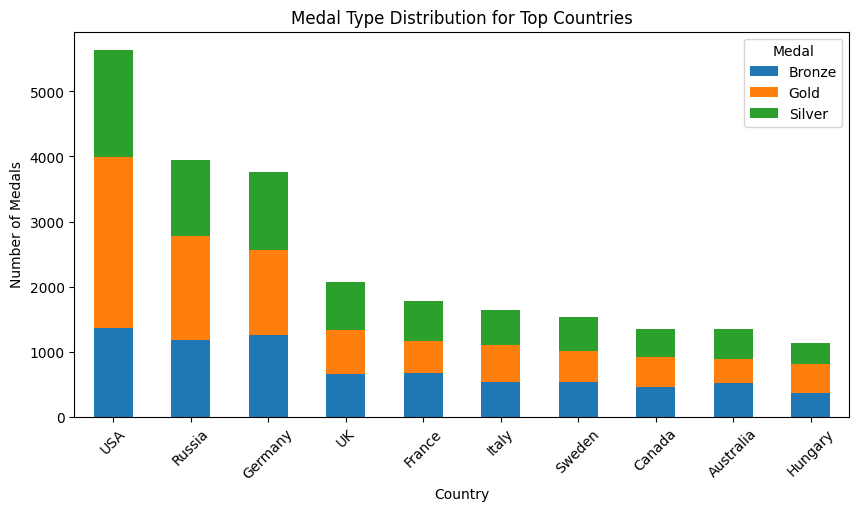

In [31]:
medal_country = df_final.groupby(['region', 'Medal']).size().unstack()

top10 = medal_country.sum(axis=1).sort_values(ascending=False).head(10).index

medal_country.loc[top10].plot(kind='bar', stacked=True, figsize=(10,5))

plt.title("Medal Type Distribution for Top Countries")
plt.xlabel("Country")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45)
plt.show()

#Why did you pick this specific chart?
A stacked bar chart was chosen because it allows comparison of total medal counts while also showing the composition of Gold, Silver, and Bronze medals for each country. It provides both category breakdown and overall ranking in a single visualization.
#What are the insights found from the chart?
The chart shows that the USA has the highest total medal count and also leads strongly in Gold medals, indicating dominant overall performance. Russia and Germany also show balanced contributions from all three medal types. Other countries have lower totals, but their medal distributions remain relatively balanced across Gold, Silver, and Bronze.

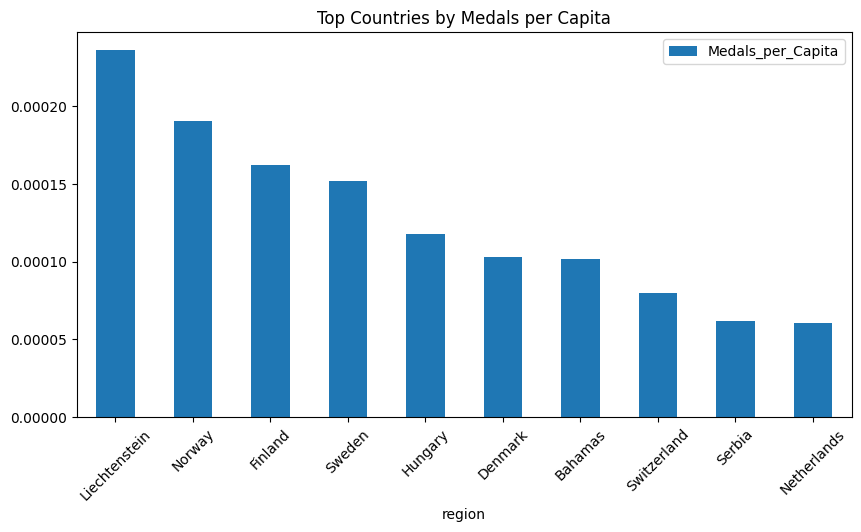

In [32]:
pop = pop[['Country (or dependency)', 'Population (2020)']]
pop.columns = ['region', 'Population']

medals_country = df_final['region'].value_counts().reset_index()
medals_country.columns = ['region', 'Medals']

medals_country['region'] = medals_country['region'].replace({
    'USA': 'United States',
    'Great Britain': 'United Kingdom',
    'Russian Federation': 'Russia'
})

merged = medals_country.merge(pop, on='region', how='left')
merged = merged.dropna()

merged['Medals_per_Capita'] = merged['Medals'] / merged['Population']

top_per_capita = merged.sort_values(by='Medals_per_Capita', ascending=False).head(10)

top_per_capita.plot(kind='bar', x='region', y='Medals_per_Capita', figsize=(10,5))
plt.title("Top Countries by Medals per Capita")
plt.xticks(rotation=45)
plt.show()

#Why did you pick this specific chart?
A bar chart was chosen because it clearly compares medals per capita across countries, making it easy to rank nations based on performance efficiency rather than total medal count. This chart provides a fairer comparison by adjusting medal counts according to population size.
#What are the insights found from the chart?
The chart reveals that smaller countries such as Liechtenstein, Norway, and Finland perform exceptionally well when medal counts are adjusted for population. This shows that countries with smaller populations can achieve higher efficiency in Olympic performance compared to larger nations, providing a more balanced perspective than total medals alone.